# 1. Loading & prep

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import os
import sys
from loguru import logger
from statsmodels.stats.outliers_influence import variance_inflation_factor
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

sys.path.append('../..')  # points to the code folder
sys.path.append('/data/cleaning-scripts/')
from config import WINDOW_LENGTH, JANUARY_CLEANING_DATE, JULY_CLEANING_DATE, FOULING_PROXY_VAR_NAME_WITH_UNIT, SPEED_VARIABLE, WEATHER_FEATURES, NON_WEATHER_FEATURES, CANDIDATE_FEATURES

In [3]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [4]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [5]:
df.columns

Index(['seg_id', 'window_start', 'Vessel Hull Over Ground Speed (knots)',
       'Vessel Hull Through Water Longitudinal Speed (knots)',
       'Vessel External Conditions Wind Relative Speed (knots)',
       'Vessel External Conditions Wind Relative Angle (degrees)',
       'Vessel Hull Heading True Angle (degrees)',
       'Vessel Hull Heading Turn Rate (deg/min)',
       'Main Engine Turbocharger Rotational Speed (rpm)',
       'Main Engine Scavenging Air Pressure (bar)',
       'Main Engine Fuel Load % (%)', 'Main Engine Rotational Speed (rpm)',
       'Vessel Propeller Shaft Torque (N*m)',
       'Vessel Propeller Shaft Mechanical Power (KW)',
       'Main Engine Fuel Oil Inlet Mass Flow (kg/hr)',
       'Vessel Propeller Shaft Mechanical Energy (KWh)',
       'Vessel Propeller Shaft Thrust Force (KN)',
       'Vessel Propeller Shaft Rotational Speed (rpm)',
       'Vessel Propeller Shaft Revolutions (cumulative) (revs)',
       'Sea Temperature Dropout', 'Calculated Shaft Power',

# 2. Correlations / VIFs

## 2.1. Correlations

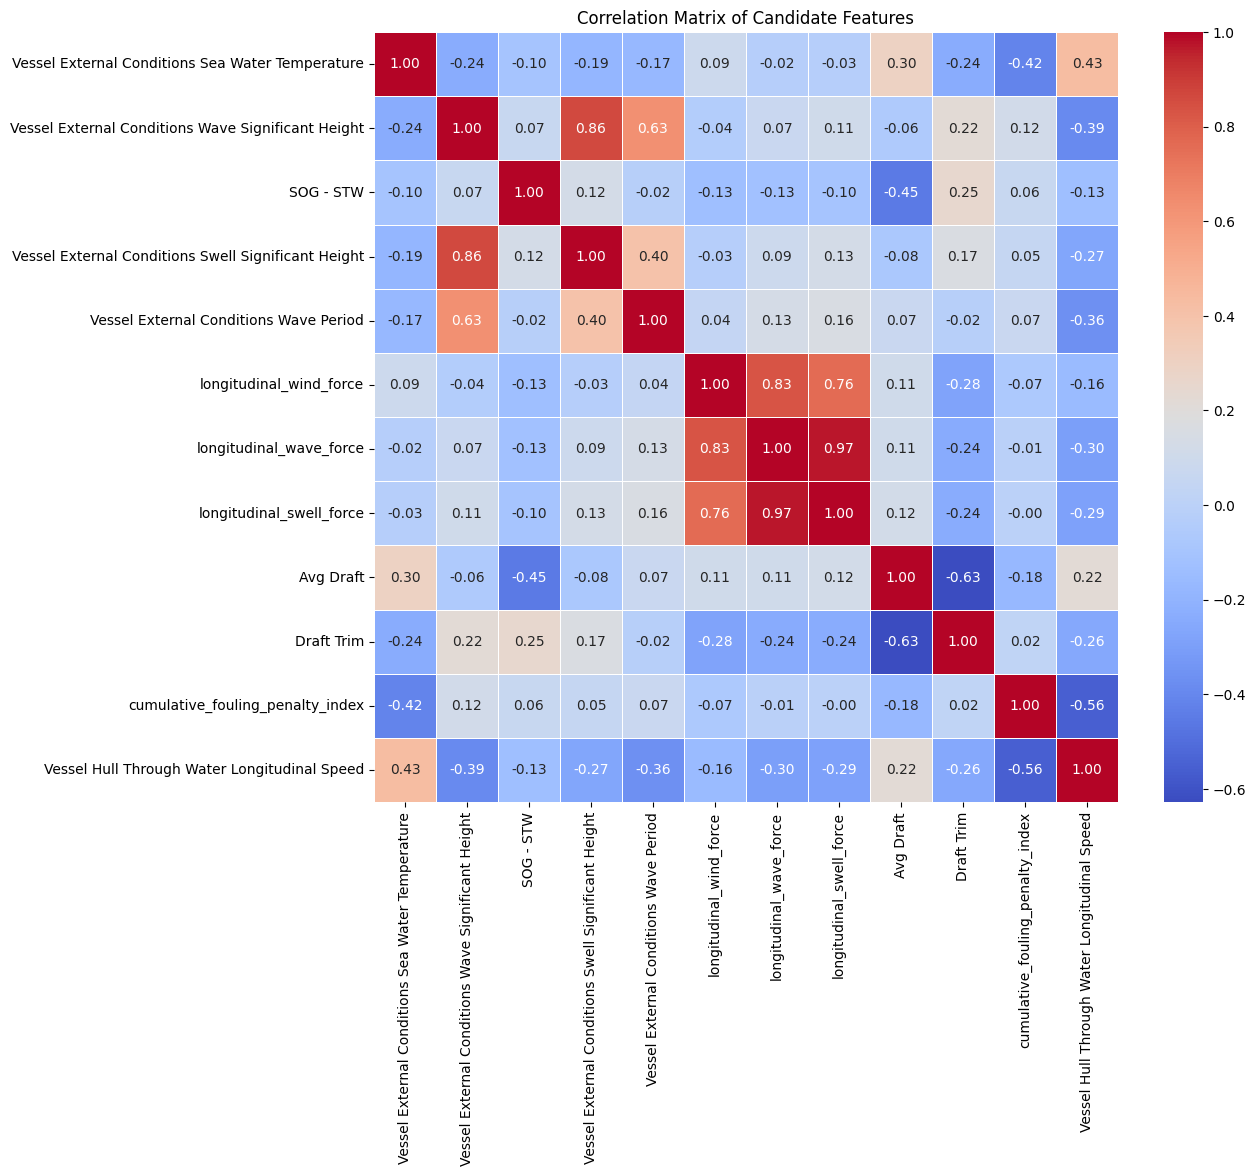

In [6]:
# make a correlation matrix between all the candidate features. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df[CANDIDATE_FEATURES].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()

## 2.2. VIFs

In [ ]:
# Based on the candidate feautures, compute all the VIF scores and sort them from highest to lowest. Print it for all the features in a readable format.
def compute_vif(df: pd.DataFrame, candidate_features: list) -> pd.DataFrame:
    """
    Compute VIF for all candidate features and return sorted DataFrame.
    Drops rows with any NaN in the candidate columns before computing.
    """
    X = df[candidate_features].dropna()
    
    vif_data = pd.DataFrame({
        "Feature": candidate_features,
        "VIF": [variance_inflation_factor(X.values, i) 
                for i in range(len(candidate_features))]
    })
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# Usage
vif_results = compute_vif(df, CANDIDATE_FEATURES)
print(vif_results.to_string(index=False))

                                                          Feature       VIF
             Vessel Hull Through Water Longitudinal Speed (knots) 53.286122
 Vessel External Conditions Wave Significant Height (Provider MB) 53.054975
    Vessel External Conditions Sea Water Temperature (Provider S) 41.184100
                             longitudinal_wave_force (calculated) 33.742742
Vessel External Conditions Swell Significant Height (Provider MB) 27.874457
                            longitudinal_swell_force (calculated) 24.245426
                                           Avg Draft (Calculated) 23.231219
              Vessel External Conditions Wave Period (Provider S) 13.476260
                                          Draft Trim (Calculated)  5.008174
                             longitudinal_wind_force (calculated)  4.635794
                    cumulative_fouling_penalty_index (calculated)  2.815759
                                           SOG - STW (calculated)  1.881854


## 2.3. Corr and VIF-based selection